In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, RationalQuadratic as RQ, Matern
from sklearn.gaussian_process.kernels import WhiteKernel, ExpSineSquared as Exp
from sklearn.gaussian_process.kernels import Kernel
from sklearn.model_selection import GridSearchCV

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import GPRmodel

Hyperparameter Optimisation

Random Search
Grid-assisted Manual Search

Sequential Model-Based Optimization (SMBO)
- Gaussian Proccess (GP)
- Tree-structured Parzen Estimator (TPE)

# Gaussian Process Regressor (GPR) Model

In [3]:
def GPR_HPopt(data, gpr, params, cv=5, verb=0):                  # TODO: Finish hopt
    grid_search = GridSearchCV(gpr, params, cv=cv, scoring="neg_mean_squared_error", verbose=verb)
    return grid_search.fit(data[0], data[1])

In [4]:
Ckernel1 = C()*Exp(length_scale=24, periodicity=1)
Ckernel2 = C()*Exp(length_scale=24, periodicity=1)*RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5))
Ckernel3 = C()*Exp(length_scale=24, periodicity=1)*(RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5)) + Exp(length_scale=24, periodicity=1))

l, l_bounds = 1, (1e-9, 1e9)
a, a_bounds = 1, (1e-9, 1e9)
p, p_bounds = 1, (1e-9, 1e9)
kernel1 = RBF(length_scale=l, length_scale_bounds=l_bounds)  # C(length, (1e-3, 1e3)) * 
kernel2 = RQ(length_scale=l, alpha=a, length_scale_bounds=l_bounds, alpha_bounds=a_bounds)
kernel3 = Matern(length_scale=l, length_scale_bounds=l_bounds, nu=1.5)
kernel4 = Exp(length_scale=l, periodicity=p, length_scale_bounds=l_bounds, periodicity_bounds=p_bounds)
kernel5 = WhiteKernel(noise_level=1e-3)

kernels = [kernel1, kernel2, kernel3, kernel4, kernel5]
alphas = [1e-5, 1e-7, 1e-9]
params = {"kernel": kernels, "alpha": alphas}

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

In [5]:
DAT = DATA(load=True, model="GPR", format=1)

In [6]:
gpr1 = GPRmodel(K=kernel1, restarts=5, alpha=1e-10, data=[DAT.train_in1, DAT.dx_out1[0]])

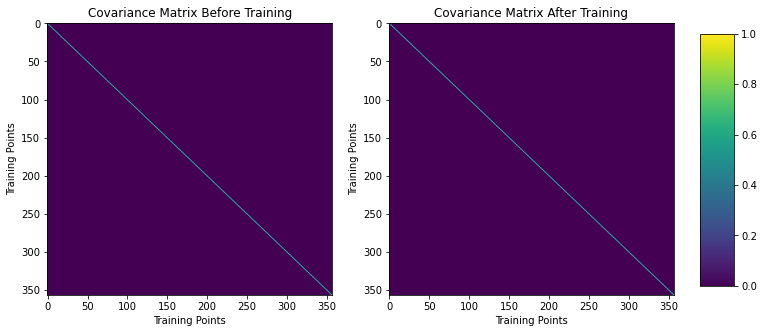

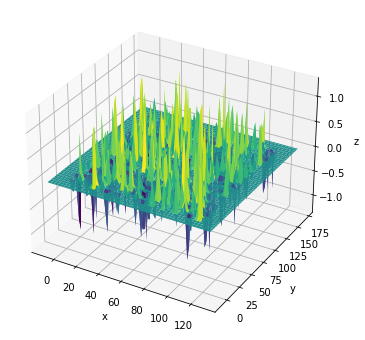

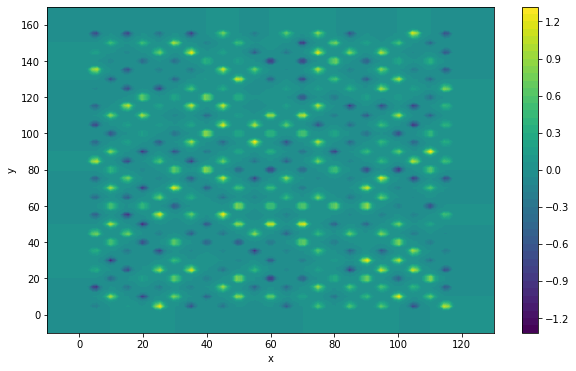

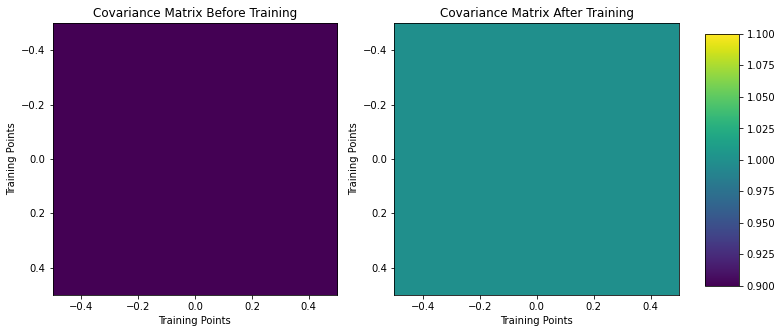

In [7]:
plot_Kmatrix(gpr1)
x_coords, y_coords, mean, std, cov = Fsurface(gpr=gpr1, density=100)
plot_Fsurface(x_coords, y_coords, mean, typ="both")
plot_Kmatrix(gpr1, x_coords)

# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [8]:
gpr2 = GPRmodel(K=kernel1, restarts=5, alpha=0.3, data=[DAT.train_in[:500], DAT.train_out[:500]])
gpr2.fit(DAT.train_in, DAT.train_out)

y_mean, y_std = gpr2.predict(DAT.test_in, return_std=True)

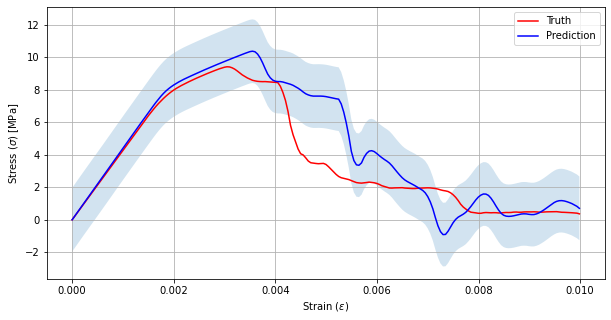

In [9]:
PLTidx = 1235

fig = plt.figure(num=1, figsize=(10,5))

plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.plot(DAT.perOUT[0], DAT.test_out[0]+DAT.perOUT[1], 'r-', label="Truth")
plt.plot(DAT.perOUT[0], y_mean[PLTidx]+DAT.perOUT[1], 'b-', label="Prediction")
plt.fill_between(DAT.perOUT[0], y_mean[PLTidx]+DAT.perOUT[1]-1.96*y_std[PLTidx], y_mean[PLTidx]+DAT.perOUT[1]+1.96*y_std[PLTidx], alpha=0.2)

plt.grid()
plt.legend()
